# Repetitive Tasks: An Inference Approach

Our Random Forest and XGBoost models were not very effective in 'predicting' repetitive tasks. If we could infer what the features/data that correlate most highly with a ticket being classified as repetitive, it would be more useful to FC&P.

This notebook uses **logistic regression** to assign interpretable weights to a curated feature space. Rather than predicting future outcomes, we want to understand *what drives* a corrective ticket to recur within 90 days — the coefficients give us log-odds weights for each feature, and we can inspect which factors most strongly increase or decrease the probability of a ticket being repetitive.

## 1. Setup & Data Loading

In [7]:
import sys
import os
sys.path.append(os.path.abspath('../utils'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from data_aggregation_tools import convert_cols_to_datetime, aggregate_surveys
from repetitive_tasks import detect_repetitive_objects


pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# Import data
df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")
df_space = pd.read_csv("../../data/V_SPACE_DETAIL.csv")
df_survey = pd.read_csv("../../data/V_OM_WORK_TASK_SURVEY.csv")


# Create mega-dataframe
df_survey_agg = aggregate_surveys(df_survey)
# df_survey_agg.to_csv("../outputs/test_surveys", index=False)

cols_to_keep = ['WORK_TASK_ID', 'RESPONSE_COMMENTS', 'AVERAGE_SURVEY_SCORE']  # only what you need
df_survey_agg = df_survey_agg[cols_to_keep]

merged_df = pd.merge(df_tickets, df_assets, on='WORK_TASK_ID', how='left')
merged_df = pd.merge(merged_df, df_survey_agg, on='WORK_TASK_ID', how='left')

buildingclass_map = (
    df_space
      .dropna(subset=["BUILDING_DESC", "BUILDING_CLASS"])
      .drop_duplicates(subset=["BUILDING_DESC"])
      .set_index("BUILDING_DESC")["BUILDING_CLASS"]
)

merged_df["BUILDING_CLASS"] = merged_df["BUILDING"].map(buildingclass_map)
merged_df = convert_cols_to_datetime(merged_df)

print(merged_df.dtypes)
print(df_tickets.shape)
merged_df.shape

print(f"Dataset shape: {merged_df.shape}")
print(f"Date range: {merged_df['CREATE_DATE_LTZ'].min()} → {merged_df['CREATE_DATE_LTZ'].max()}")
merged_df.head(3)


/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_19141/1812350695.py:20: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_19141/1812350695.py:21: DtypeWarning: Columns (0,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")


WORK_TASK_ID                               object
WORK_TASK_NAME_x                           object
WORK_TASK_STATUS_x                         object
RICE_WORK_STATUS                           object
ASSIGNMENT_STATUS                          object
DESCRIPTION                                object
TASK_TYPE                                  object
TASK_PRIORITY                              object
REQUEST_CLASS                              object
SERVICE_CLASS                              object
PRIMARY_LOCATION                           object
PROPERTY                                   object
BUILDING                                   object
FLOOR                                      object
SPACE                                      object
GEOGRAPHY_LOOKUP                           object
CUSTOMER_ORGANIZATION                      object
CUSTOMER_COMPANY                           object
CUSTOMER_DIVISION                          object
CUSTOMER_DEPARTMENT                        object


,WORK_TASK_ID,WORK_TASK_NAME_x,WORK_TASK_STATUS_x,RICE_WORK_STATUS,ASSIGNMENT_STATUS,DESCRIPTION,TASK_TYPE,TASK_PRIORITY,REQUEST_CLASS,SERVICE_CLASS,PRIMARY_LOCATION,PROPERTY,BUILDING,FLOOR,SPACE,GEOGRAPHY_LOOKUP,CUSTOMER_ORGANIZATION,CUSTOMER_COMPANY,CUSTOMER_DIVISION,CUSTOMER_DEPARTMENT,RESPONSIBLE_ORGANIZATION_NAME,ORGANIZATION_TYPE,RESPONSIBLE_ORGANIZATION_PATH,RESPONSIBLE_PERSON_NAME,RESPONSIBLE_PERSON_EMAIL,RESPONSIBLE_PERSON_WORKPHONE,BASELINE_START_LTZ,BASELINE_END_LTZ,ASSIGNED_DATE_LTZ,PLANNED_START_LTZ,PLANNED_END_LTZ,PLANNED_FOLLOW_UP_DATE_LTZ,PLANNED_WORKING_DAYS,PLANNED_COST,ACTUAL_START_LTZ,ACTUAL_END_LTZ,RICE_ACTUAL_COST,REVERSAL,BILLING_TYPE,ACCOUNTING_HOLD,ACCOUNTING_HOLD_REASON,COA_ACCOUNT_STRING,POETAF_ACCOUNT_STRING,NUMBER_OF_ASSETS,RESOLUTION_DESCRIPTION,CAPITAL_PROJECT_ID,CREATE_DATE_LTZ,WORK_TASK_NAME_y,WORK_TASK_STATUS_y,ASSET_ID,ASSET_NAME,ASSET_STATUS,ASSET_PRIMARY_LOCATION,ASSET_PRIMARY_LOCATION_BUILDING,ACCOUNT_STRING,RESPONSE_COMMENTS,AVERAGE_SURVEY_SCORE,BUILDING_CLASS
0,1302351,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,student at Jones North room 129 has hand foot ...,Corrective,3 - Routine,Custodial Issues,Custodial,\Locations\Rice\Mary Gibbs Jones College - Nor...,Rice,Mary Gibbs Jones College - North,01,129,\Geography\North America\United States\Texas\H...,\Organizations\Rice\Dean of Undergraduates\Stu...,Rice,Dean of Undergraduates,Student Health Services,HD Custodial,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Melissa Salinas,melissasalinas@rice.edu,713-348-8264,2025-09-19 08:24:42,2025-10-10 08:24:42,2025-09-19 08:24:45,2025-09-19 08:24:42,2025-10-10 08:24:42,2025-09-21 08:24:42,21.0,NaN,2025-09-19 08:24:42,2025-09-22 10:36:51,0.0,False,Billable,No,NaN,"10,84100,103,030000,8985,800,9999,9999,999,999",NaN,0,NaN,NaN,2025-09-19 08:24:42,RICE - DEFAULT - Work Task Template - Correcti...,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Residence Hall
1,1302352,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management Support,Capital Projects,\Locations\Rice\George R. Brown Hall,Rice,George R. Brown Hall,NaN,NaN,\Geography\North America\United States\Texas\H...,NaN,NaN,NaN,NaN,00 FE&P Administration,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Pamela Marut,pm12@rice.edu,NaN,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,0.0,NaN,2025-09-19 08:30:07,2026-01-14 08:38:10,0.0,False,Billable,No,NaN,"10,00100,100,000000,1087,500,9999,9999,999,999","C10000442,86000,NC Project Management Support ...",0,NaN,C10000442,2025-09-19 08:30:07,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sci. Research
2,1302353,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management Support,Capital Projects,\Locations\Rice\George R. Brown Hall,Rice,George R. Brown Hall,NaN,NaN,\Geography\North America\United States\Texas\H...,NaN,NaN,NaN,NaN,14 Facilities Project Managers,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Troy Christmas,Troy.W.Christmas@rice.edu,NaN,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,0.0,NaN,2025-09-19 08:30:12,2026-01-14 08:38:21,0.0,False,Billable,No,NaN,"10,00100,100,000000,1087,999,9999,9999,999,999","C10000442,86000,NC Project Management Support ...",0,NaN,C10000442,2025-09-19 08:30:12,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sci. Research


## 2. Label Repetitive Tasks

We use `detect_repetitive_objects` (from `repetitive_tasks.py`) with the same grouping columns and time window as the prediction notebook:
- **Group columns**: `SERVICE_CLASS`, `BUILDING`, `FLOOR`, `SPACE` — defines a unique "maintenance object" (a location + service type)
- **Window**: 3–90 days — a subsequent corrective ticket on the same object within this window flags the first as repetitive

Since only corrective tickets can be repetitive by definition, we filter to `TASK_TYPE == 'Corrective'` before fitting the model.

In [8]:
GROUP_COLS = ["SERVICE_CLASS", "BUILDING", "FLOOR", "SPACE"]
NUM_DAYS = 90
MIN_DAYS = 3

df_repetitive, object_repetitive_dict, all_objects_dict = detect_repetitive_objects(
    merged_df.copy(),
    group_cols=GROUP_COLS,
    num_days=NUM_DAYS,
    min_days=MIN_DAYS,
    verbose=True
)

90 days 00:00:00
Number of rows pre-corrective: 312158
Number of corrective tasks: 100965
Number of unique objects (groups): 29313
Found 14703 repetitive tasks by object within 90 days.


In [11]:
# Match repetitive tickets back to the original dataframe via WORK_TASK_ID
repetitive_ids = set(df_repetitive['WORK_TASK_ID'].dropna().astype(str))

# Work only on corrective tickets for modeling
df_corr = merged_df[merged_df['TASK_TYPE'] == 'Corrective'].copy().reset_index(drop=True)
df_corr['IS_REPETITIVE'] = df_corr['WORK_TASK_ID'].astype(str).isin(repetitive_ids).astype(int)

print(f"Corrective tickets: {len(df_corr):,}")
print(f"Labeled repetitive: {df_corr['IS_REPETITIVE'].sum():,} ({df_corr['IS_REPETITIVE'].mean():.1%})")
print(f"Labeled non-repetitive: {(df_corr['IS_REPETITIVE'] == 0).sum():,} ({(df_corr['IS_REPETITIVE'] == 0).mean():.1%})")

Corrective tickets: 100,965
Labeled repetitive: 14,703 (14.6%)
Labeled non-repetitive: 86,262 (85.4%)


## 3. Feature Engineering

We construct the following feature space:

| Feature | Type | Description |
|---|---|---|
| `NUMBER_OF_ASSETS_CLIPPED` | Numeric | Assets on the ticket (capped at 99th percentile) |
| `HAS_SPACE_PM` | Binary | Does this object (SERVICE_CLASS + BUILDING + FLOOR + SPACE) have any non-corrective work? |
| `BUILDING_CONDITION_SCORE` | Numeric | Proportion of all tickets in the building that are corrective (higher = worse condition) |
| `DAYS_TO_START` | Numeric | Days from ticket assignment to work starting (`ACTUAL_START - ASSIGNED_DATE`); median-imputed if missing |
| `DAYS_TO_COMPLETE` | Numeric | Days from work start to completion (`ACTUAL_END - ACTUAL_START`); median-imputed if missing |
| `HAS_ACTUAL_START` | Binary | Was the ticket ever actually started? |
| `HAS_ACTUAL_END` | Binary | Was the ticket ever completed? |
| `COMPLETED_IN_19_DAYS` | Binary | Was the ticket resolved within 19 days of its creation date? |
| `IS_FIRST_FLOOR` | Binary | Is the ticket on the first floor? |
| `DESCRIPTION_SENTIMENT` | Numeric | VADER compound sentiment score of the ticket description (−1 to +1); 0 if missing |
| `RESOLUTION_DESCRIPTION_SENTIMENT` | Numeric | VADER compound sentiment score of the resolution description (−1 to +1); 0 if missing |
| `RESPONSE_COMMENTS_SENTIMENT` | Numeric | VADER compound sentiment score of the customer survey response (−1 to +1); 0 if missing |
| `SVC_*` | One-hot | Service class (top 8 categories, reference = most common) |
| `ORG_*` | One-hot | Responsible organization (top 8, reference = most common) |
| `DOW_*` | One-hot | Day of week ticket was created (0=Mon … 6=Sun) |
| `MONTH_*` | One-hot | Month ticket was created (1–12) |

In [12]:
# --- Feature: Preventive Maintenance Coverage ---
# Derived from the FULL dataset (all task types), NOT from df_corr.
# A building or space with any non-corrective activity (preventive, inspection,
# planned, etc.) is considered to have proactive maintenance coverage.
#
# We use only the SPACE-level flag (HAS_SPACE_PM) — it's the more granular
# signal and implicitly encodes building-level PM coverage too (a space can't
# have PM unless its building does). Including both would introduce hierarchical
# multicollinearity since HAS_SPACE_PM=1 always implies HAS_BUILDING_PM=1.

df_non_corr = merged_df[merged_df['TASK_TYPE'] != 'Corrective'].copy()

# Space-level: does this specific object (SERVICE_CLASS + BUILDING + FLOOR + SPACE) have non-corrective work?
make_key = lambda d: d[GROUP_COLS].fillna('NaN').astype(str).apply('|'.join, axis=1)
pm_objects = set(make_key(df_non_corr))
df_corr['object_key'] = make_key(df_corr)
df_corr['HAS_SPACE_PM'] = df_corr['object_key'].isin(pm_objects).astype(int)

print("Preventive Maintenance Coverage (among corrective tickets):")
print(f"  Spaces with non-corrective work: {df_corr['HAS_SPACE_PM'].mean():.1%}")
print()
print("Repetitive rate by space PM coverage:")
rep_by_pm = df_corr.groupby('HAS_SPACE_PM')['IS_REPETITIVE'].mean()
rep_by_pm.index = rep_by_pm.index.map({0: 'No PM', 1: 'Has PM'})
print(rep_by_pm.to_string())

Preventive Maintenance Coverage (among corrective tickets):
  Spaces with non-corrective work: 7.8%

Repetitive rate by space PM coverage:
HAS_SPACE_PM
No PM     0.150649
Has PM    0.086334


Total corrective tickets:                  100,965
  With space-level detail (FLOOR + SPACE): 69,261 (68.6%)
    → Also have space-level PM:            1,917 (2.8% of those with detail)
    → No matching PM at space level:       67,344 (97.2% of those with detail)
  Without space-level detail:              31,704 (31.4%)


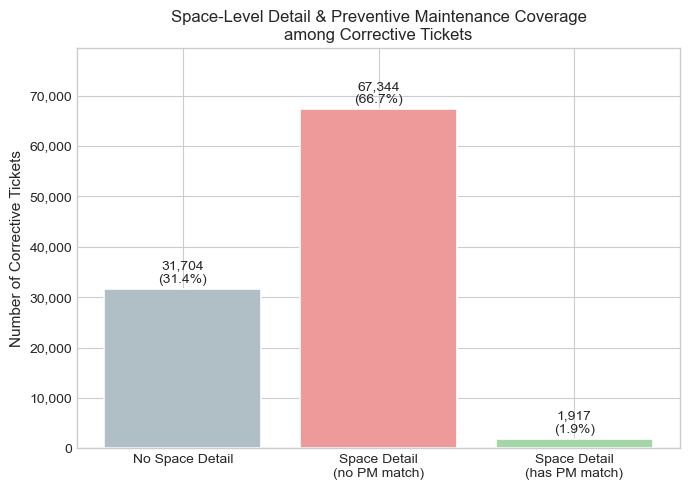

In [13]:
# --- Coverage Check: Space-Level Detail & PM Overlap ---
# "Space-level detail" = ticket has non-null values for both FLOOR and SPACE.
# This shows how many corrective tickets are specific enough to match a PM object,
# and of those, how many actually have associated preventive work.

has_space_detail = df_corr['FLOOR'].notna() & df_corr['SPACE'].notna()

n_total        = len(df_corr)
n_space_detail = has_space_detail.sum()
n_space_pm     = (has_space_detail & (df_corr['HAS_SPACE_PM'] == 1)).sum()
n_no_detail    = (~has_space_detail).sum()
n_detail_no_pm = (has_space_detail & (df_corr['HAS_SPACE_PM'] == 0)).sum()

print(f"Total corrective tickets:                  {n_total:,}")
print(f"  With space-level detail (FLOOR + SPACE): {n_space_detail:,} ({n_space_detail/n_total:.1%})")
print(f"    → Also have space-level PM:            {n_space_pm:,} ({n_space_pm/n_space_detail:.1%} of those with detail)")
print(f"    → No matching PM at space level:       {n_detail_no_pm:,} ({n_detail_no_pm/n_space_detail:.1%} of those with detail)")
print(f"  Without space-level detail:              {n_no_detail:,} ({n_no_detail/n_total:.1%})")

# Stacked bar chart
fig, ax = plt.subplots(figsize=(7, 5))

categories = ['No Space Detail', 'Space Detail\n(no PM match)', 'Space Detail\n(has PM match)']
values     = [n_no_detail, n_detail_no_pm, n_space_pm]
colors     = ['#b0bec5', '#ef9a9a', '#a5d6a7']

bars = ax.bar(categories, values, color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + n_total * 0.005,
        f'{val:,}\n({val/n_total:.1%})',
        ha='center', va='bottom', fontsize=10
    )

ax.set_ylabel('Number of Corrective Tickets', fontsize=11)
ax.set_title('Space-Level Detail & Preventive Maintenance Coverage\namong Corrective Tickets', fontsize=12)
ax.set_ylim(0, max(values) * 1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [14]:
# --- Feature: Building Condition Score ---
# Proportion of ALL tickets in a building that are corrective.
# A high corrective ratio indicates poor maintenance condition —
# the building is reactive rather than proactive.
# This is computed from the full dataset (not just corrective), so it's non-circular.

building_stats = (
    merged_df.groupby('BUILDING')
    .agg(
        total_tickets=('WORK_TASK_ID', 'count'),
        corrective_count=('TASK_TYPE', lambda x: (x == 'Corrective').sum())
    )
    .assign(BUILDING_CONDITION_SCORE=lambda x: x['corrective_count'] / x['total_tickets'])
    .reset_index()
)

df_corr = df_corr.merge(building_stats[['BUILDING', 'BUILDING_CONDITION_SCORE']], on='BUILDING', how='left')

print("Building Condition Score distribution:")
print(df_corr['BUILDING_CONDITION_SCORE'].describe())
print(f"\nCorrelation with IS_REPETITIVE: {df_corr[['BUILDING_CONDITION_SCORE', 'IS_REPETITIVE']].corr().iloc[0, 1]:.4f}")

Building Condition Score distribution:
count    100936.000000
mean          0.369027
std           0.129433
min           0.007407
25%           0.277942
50%           0.352437
75%           0.452567
max           1.000000
Name: BUILDING_CONDITION_SCORE, dtype: float64

Correlation with IS_REPETITIVE: 0.0030


In [17]:
# --- Feature: Time Deltas ---
# DAYS_TO_START:    ACTUAL_START_LTZ - ASSIGNED_DATE_LTZ
#   (how long a ticket sat in the queue before work began)
# DAYS_TO_COMPLETE: ACTUAL_END_LTZ - ACTUAL_START_LTZ
#   (how long the actual work took once started)

df_corr['ACTUAL_START_LTZ']  = pd.to_datetime(df_corr['ACTUAL_START_LTZ'],  errors='coerce')
df_corr['ACTUAL_END_LTZ']    = pd.to_datetime(df_corr['ACTUAL_END_LTZ'],    errors='coerce')
df_corr['ASSIGNED_DATE_LTZ'] = pd.to_datetime(df_corr['ASSIGNED_DATE_LTZ'], errors='coerce')

df_corr['HAS_ACTUAL_START'] = df_corr['ACTUAL_START_LTZ'].notna().astype(int)
df_corr['HAS_ACTUAL_END']   = df_corr['ACTUAL_END_LTZ'].notna().astype(int)

raw_days_to_start    = (df_corr['ACTUAL_START_LTZ'] - df_corr['ASSIGNED_DATE_LTZ']).dt.total_seconds() / 86400
raw_days_to_complete = (df_corr['ACTUAL_END_LTZ']   - df_corr['ACTUAL_START_LTZ']).dt.total_seconds()  / 86400

# Clip at 99th percentile before imputing so outliers don't skew the median
p99_start    = raw_days_to_start.quantile(0.99)
p99_complete = raw_days_to_complete.quantile(0.99)

df_corr['DAYS_TO_START']    = raw_days_to_start.clip(upper=p99_start).fillna(raw_days_to_start.median())
df_corr['DAYS_TO_COMPLETE'] = raw_days_to_complete.clip(upper=p99_complete).fillna(raw_days_to_complete.median())

print("Time delta distributions (after clipping & imputation):")
print(df_corr[['DAYS_TO_START', 'DAYS_TO_COMPLETE']].describe().round(2))
print(f"\nTickets missing ACTUAL_START: {(df_corr['HAS_ACTUAL_START']==0).sum():,} ({(df_corr['HAS_ACTUAL_START']==0).mean():.1%})")
print(f"Tickets missing ACTUAL_END:   {(df_corr['HAS_ACTUAL_END']==0).sum():,} ({(df_corr['HAS_ACTUAL_END']==0).mean():.1%})")

# --- Feature: First Floor ---
# Binary flag: is the ticket on the first floor?
# First-floor spaces (lobbies, entrances, common areas) may have different
# failure patterns than upper floors.
df_corr['IS_FIRST_FLOOR'] = (pd.to_numeric(df_corr['FLOOR'], errors='coerce') == 1).astype(int)
print(f"\nFirst-floor tickets: {df_corr['IS_FIRST_FLOOR'].sum():,} ({df_corr['IS_FIRST_FLOOR'].mean():.1%})")

# --- Feature: Temporal Flags ---
df_corr['day_of_week'] = df_corr['CREATE_DATE_LTZ'].dt.dayofweek
df_corr['month']       = df_corr['CREATE_DATE_LTZ'].dt.month
df_corr['quarter']     = df_corr['CREATE_DATE_LTZ'].dt.quarter
df_corr['day_of_month'] = df_corr['CREATE_DATE_LTZ'].dt.day
df_corr['week_of_year'] = df_corr['CREATE_DATE_LTZ'].dt.isocalendar().week
print(f"\nday_of_week range: {df_corr['day_of_week'].min()}–{df_corr['day_of_week'].max()}")
print(f"month range:        {df_corr['month'].min()}–{df_corr['month'].max()}")

# --- Feature: Completed in 19 Days ---
# Binary flag: was the ticket fully resolved within 19 days of its creation date?
# This captures whether the issue was handled quickly end-to-end, as opposed to
# sitting open for an extended period — which may correlate with unresolved problems
# that recur. Tickets with no ACTUAL_END are treated as not completed within 19 days.
df_corr['CREATE_DATE_LTZ'] = pd.to_datetime(df_corr['CREATE_DATE_LTZ'], errors='coerce')
days_creation_to_end = (df_corr['ACTUAL_END_LTZ'] - df_corr['CREATE_DATE_LTZ']).dt.total_seconds() / 86400
df_corr['COMPLETED_IN_19_DAYS'] = ((days_creation_to_end >= 0) & (days_creation_to_end <= 19)).astype(int)

print(f"Completed within 19 days of creation: {df_corr['COMPLETED_IN_19_DAYS'].sum():,} ({df_corr['COMPLETED_IN_19_DAYS'].mean():.1%})")
print(f"Repetitive rate — completed ≤19 days: {df_corr[df_corr['COMPLETED_IN_19_DAYS']==1]['IS_REPETITIVE'].mean():.1%}")
print(f"Repetitive rate — completed >19 days: {df_corr[df_corr['COMPLETED_IN_19_DAYS']==0]['IS_REPETITIVE'].mean():.1%}")

Time delta distributions (after clipping & imputation):
       DAYS_TO_START  DAYS_TO_COMPLETE
count      100965.00         100965.00
mean            1.77             33.15
std           147.92            112.89
min        -20026.74         -18925.72
25%             0.02              2.13
50%             0.19              7.81
75%             1.20             25.03
max            88.75            491.17

Tickets missing ACTUAL_START: 3,105 (3.1%)
Tickets missing ACTUAL_END:   5,469 (5.4%)

First-floor tickets: 37,460 (37.1%)

day_of_week range: 0–6
month range:        1–12
Completed within 19 days of creation: 60,575 (60.0%)
Repetitive rate — completed ≤19 days: 14.6%
Repetitive rate — completed >19 days: 14.6%


In [18]:
# --- Feature: Sentiment Scores ---
# VADER compound scores for the three free-text fields on each ticket.
# Scores are in [-1.0, 1.0]: negative values indicate negative language,
# positive values indicate positive language, 0 is neutral.
# Null/empty text returns NaN — filled with 0 (neutral) during feature assembly.
#
# Note: RESOLUTION_DESCRIPTION and RESPONSE_COMMENTS must be present in df_corr.
# If loading from a source that does not include them, merge them in beforehand.

from sentiments import sentiment_score

for col in ["DESCRIPTION", "RESOLUTION_DESCRIPTION", "RESPONSE_COMMENTS"]:
    df_corr[f"{col}_SENTIMENT"] = df_corr[col].apply(sentiment_score)

sentiment_cols = ["DESCRIPTION_SENTIMENT", "RESOLUTION_DESCRIPTION_SENTIMENT", "RESPONSE_COMMENTS_SENTIMENT"]

print("Sentiment score distributions:")
print(df_corr[sentiment_cols].describe().round(3))
print()
print("Null rates (will be filled with 0 = neutral before modelling):")
for col in sentiment_cols:
    print(f"  {col}: {df_corr[col].isna().mean():.1%} null")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/beckedwards/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Sentiment score distributions:
       DESCRIPTION_SENTIMENT  RESOLUTION_DESCRIPTION_SENTIMENT  \
count             100779.000                         59545.000   
mean                   0.053                            -0.016   
std                    0.336                             0.278   
min                   -0.999                            -0.982   
25%                    0.000                             0.000   
50%                    0.000                             0.000   
75%                    0.318                             0.000   
max                    0.989                             0.977   

       RESPONSE_COMMENTS_SENTIMENT  
count                      814.000  
mean                         0.317  
std                          0.419  
min                         -0.918  
25%                          0.000  
50%                          0.422  
75%                          0.647  
max                          0.990  

Null rates (will be filled with 0 = neut

In [19]:
# --- Categorical Features: SERVICE_CLASS, RESPONSIBLE_ORGANIZATION_NAME,
#                           DAY_OF_WEEK, MONTH ---

# SERVICE_CLASS: top 8, lump rest as 'Other'
top_service_classes = df_corr['SERVICE_CLASS'].value_counts().head(8).index
df_corr['SERVICE_CLASS_CLEAN'] = df_corr['SERVICE_CLASS'].where(
    df_corr['SERVICE_CLASS'].isin(top_service_classes), other='Other'
)

# RESPONSIBLE_ORGANIZATION_NAME: top 8, lump rest as 'Other'
top_orgs = df_corr['RESPONSIBLE_ORGANIZATION_NAME'].value_counts().head(8).index
df_corr['ORG_CLEAN'] = df_corr['RESPONSIBLE_ORGANIZATION_NAME'].where(
    df_corr['RESPONSIBLE_ORGANIZATION_NAME'].isin(top_orgs), other='Other'
).fillna('Other')

# Temporal: day_of_week (0=Mon … 6=Sun) and month (1–12)
# Quarter is skipped — it's directly derivable from month, adding collinearity.
# week_of_year and day_of_month are too granular for a linear model.
df_corr['DOW_CLEAN']   = df_corr['day_of_week'].astype(str)
df_corr['MONTH_CLEAN'] = df_corr['month'].astype(str)

# One-hot encode all categoricals (drop_first=True to avoid dummy variable trap)
service_dummies = pd.get_dummies(df_corr['SERVICE_CLASS_CLEAN'], prefix='SVC',   drop_first=True)
org_dummies     = pd.get_dummies(df_corr['ORG_CLEAN'],           prefix='ORG',   drop_first=True)
dow_dummies     = pd.get_dummies(df_corr['DOW_CLEAN'],           prefix='DOW',   drop_first=True)
month_dummies   = pd.get_dummies(df_corr['MONTH_CLEAN'],         prefix='MONTH', drop_first=True)

# NUMBER_OF_ASSETS: clip at 99th percentile
cap_99 = df_corr['NUMBER_OF_ASSETS'].quantile(0.99)
df_corr['NUMBER_OF_ASSETS_CLIPPED'] = df_corr['NUMBER_OF_ASSETS'].clip(upper=cap_99)

# --- Assemble Feature Matrix ---
base_features = [
    # Asset / ticket properties
    'NUMBER_OF_ASSETS_CLIPPED',
    # PM coverage
    'HAS_SPACE_PM',
    # Building health
    'BUILDING_CONDITION_SCORE',
    # Time-to-action features
    'DAYS_TO_START',
    'DAYS_TO_COMPLETE',
    'HAS_ACTUAL_START',
    'HAS_ACTUAL_END',
    'COMPLETED_IN_19_DAYS',
    # Location
    'IS_FIRST_FLOOR',
    # Sentiment scores (NaN filled with 0 = neutral via .fillna(0) below)
    'DESCRIPTION_SENTIMENT',
    'RESOLUTION_DESCRIPTION_SENTIMENT',
    'RESPONSE_COMMENTS_SENTIMENT',
]

X = pd.concat([
    df_corr[base_features].reset_index(drop=True),
    service_dummies.reset_index(drop=True),
    org_dummies.reset_index(drop=True),
    dow_dummies.reset_index(drop=True),
    month_dummies.reset_index(drop=True),
], axis=1).fillna(0)

y = df_corr['IS_REPETITIVE'].reset_index(drop=True)

print(f"Feature matrix shape: {X.shape}")
print(f"\nFeature groups:")
print(f"  Base numeric:  {base_features}")
print(f"  SVC dummies:   {service_dummies.columns.tolist()}")
print(f"  ORG dummies:   {org_dummies.columns.tolist()}")
print(f"  DOW dummies:   {dow_dummies.columns.tolist()}")
print(f"  MONTH dummies: {month_dummies.columns.tolist()}")

Feature matrix shape: (100965, 45)

Feature groups:
  Base numeric:  ['NUMBER_OF_ASSETS_CLIPPED', 'HAS_SPACE_PM', 'BUILDING_CONDITION_SCORE', 'DAYS_TO_START', 'DAYS_TO_COMPLETE', 'HAS_ACTUAL_START', 'HAS_ACTUAL_END', 'COMPLETED_IN_19_DAYS', 'IS_FIRST_FLOOR', 'DESCRIPTION_SENTIMENT', 'RESOLUTION_DESCRIPTION_SENTIMENT', 'RESPONSE_COMMENTS_SENTIMENT']
  SVC dummies:   ['SVC_Building Interior', 'SVC_Carpentry', 'SVC_Custodial', 'SVC_Electrical', 'SVC_Facilities', 'SVC_HVAC', 'SVC_Other', 'SVC_Plumbing']
  ORG dummies:   ['ORG_02 Plumbing', 'ORG_03 Electrical', 'ORG_04 Carpentry Exterior & Painting', 'ORG_08 Elevator', 'ORG_11 Grounds Operations & Specialists', 'ORG_18 Controls', 'ORG_HD Maintenance', 'ORG_Other']
  DOW dummies:   ['DOW_1', 'DOW_2', 'DOW_3', 'DOW_4', 'DOW_5', 'DOW_6']
  MONTH dummies: ['MONTH_10', 'MONTH_11', 'MONTH_12', 'MONTH_2', 'MONTH_3', 'MONTH_4', 'MONTH_5', 'MONTH_6', 'MONTH_7', 'MONTH_8', 'MONTH_9']


## 4. Multicollinearity Analysis

Before fitting the model, we check for multicollinearity — features that are highly correlated with each other inflate standard errors and make coefficient estimates unreliable.

- **Pearson correlation matrix**: flag pairs with |r| > 0.7
- **Variance Inflation Factor (VIF)**: VIF > 10 indicates problematic collinearity and the feature should be dropped

/Users/beckedwards/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


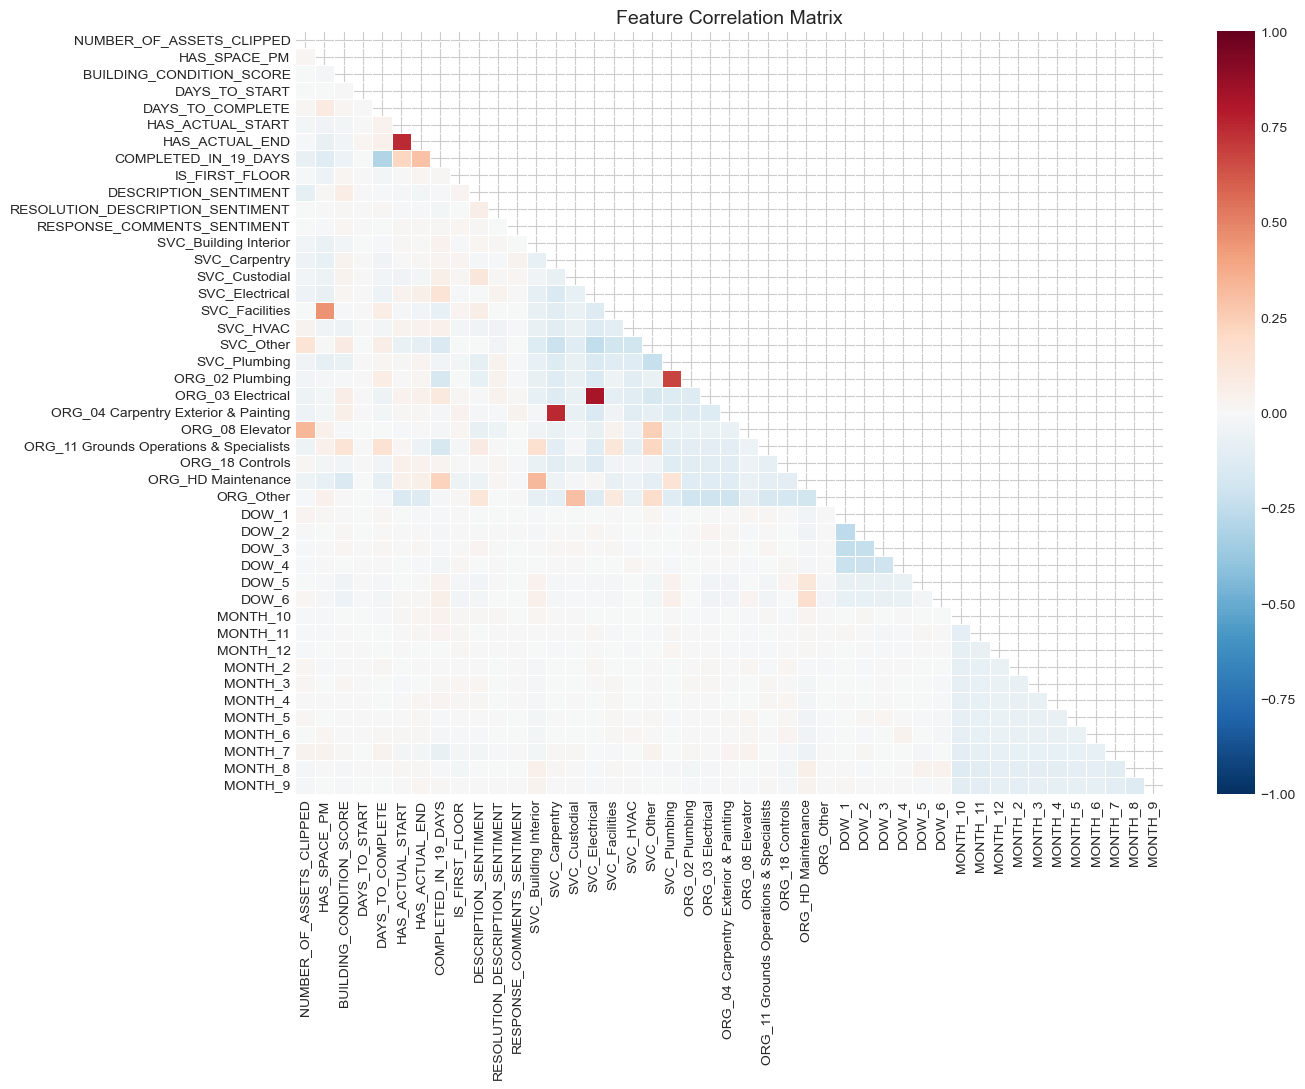

High-correlation pairs (|r| > 0.7):
       Feature A                            Feature B  Correlation
HAS_ACTUAL_START                       HAS_ACTUAL_END        0.744
   SVC_Carpentry ORG_04 Carpentry Exterior & Painting        0.751
  SVC_Electrical                    ORG_03 Electrical        0.823


In [20]:
# --- Correlation Heatmap ---
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Report high-correlation pairs
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

print("High-correlation pairs (|r| > 0.7):")
if high_corr:
    print(pd.DataFrame(high_corr, columns=['Feature A', 'Feature B', 'Correlation']).to_string(index=False))
else:
    print("None found.")

In [21]:
# --- Variance Inflation Factor ---
X_vif = X.astype(float)
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("Variance Inflation Factors:")
print(vif_data.to_string(index=False))
print()
print("Rule of thumb: VIF > 10 → drop feature (severe collinearity)")
print("               VIF 5–10 → investigate further")

Variance Inflation Factors:
                                Feature       VIF
                       HAS_ACTUAL_START 62.097823
                         HAS_ACTUAL_END 44.977767
               BUILDING_CONDITION_SCORE  8.851942
                         SVC_Electrical  6.356011
                              SVC_Other  5.828893
                      ORG_03 Electrical  5.761105
   ORG_04 Carpentry Exterior & Painting  4.682966
                          SVC_Carpentry  4.656867
                              ORG_Other  4.623634
                           SVC_Plumbing  4.578169
                        ORG_02 Plumbing  4.085691
                   COMPLETED_IN_19_DAYS  3.474682
                     ORG_HD Maintenance  3.092616
                         SVC_Facilities  2.918062
                               SVC_HVAC  2.660627
ORG_11 Grounds Operations & Specialists  2.573091
                        ORG_18 Controls  2.451558
                                MONTH_8  2.174694
                  SVC_

In [22]:
# --- Drop High-VIF Features ---
HIGH_VIF_THRESHOLD = 10

cols_to_drop = vif_data[vif_data['VIF'] > HIGH_VIF_THRESHOLD]['Feature'].tolist()

if cols_to_drop:
    print(f"Dropping {len(cols_to_drop)} high-VIF column(s): {cols_to_drop}")
    X_clean = X.drop(columns=cols_to_drop)
else:
    print("No columns exceed VIF threshold.")
    X_clean = X.copy()

# Drop zero-variance (constant) columns — a constant column makes the Hessian singular
constant_cols = [col for col in X_clean.columns if X_clean[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping {len(constant_cols)} constant column(s): {constant_cols}")
    X_clean = X_clean.drop(columns=constant_cols)

# Drop one column from each pair with |r| >= 0.999 (perfect collinearity not caught by VIF)
corr_abs = X_clean.corr().abs()
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
perfect_corr_cols = [col for col in upper_tri.columns if (upper_tri[col] >= 0.999).any()]
if perfect_corr_cols:
    print(f"Dropping {len(perfect_corr_cols)} perfectly-correlated column(s): {perfect_corr_cols}")
    X_clean = X_clean.drop(columns=perfect_corr_cols)

print(f"\nFinal feature count: {X_clean.shape[1]}")
print(f"Final features: {X_clean.columns.tolist()}")

Dropping 2 high-VIF column(s): ['HAS_ACTUAL_START', 'HAS_ACTUAL_END']

Final feature count: 43
Final features: ['NUMBER_OF_ASSETS_CLIPPED', 'HAS_SPACE_PM', 'BUILDING_CONDITION_SCORE', 'DAYS_TO_START', 'DAYS_TO_COMPLETE', 'COMPLETED_IN_19_DAYS', 'IS_FIRST_FLOOR', 'DESCRIPTION_SENTIMENT', 'RESOLUTION_DESCRIPTION_SENTIMENT', 'RESPONSE_COMMENTS_SENTIMENT', 'SVC_Building Interior', 'SVC_Carpentry', 'SVC_Custodial', 'SVC_Electrical', 'SVC_Facilities', 'SVC_HVAC', 'SVC_Other', 'SVC_Plumbing', 'ORG_02 Plumbing', 'ORG_03 Electrical', 'ORG_04 Carpentry Exterior & Painting', 'ORG_08 Elevator', 'ORG_11 Grounds Operations & Specialists', 'ORG_18 Controls', 'ORG_HD Maintenance', 'ORG_Other', 'DOW_1', 'DOW_2', 'DOW_3', 'DOW_4', 'DOW_5', 'DOW_6', 'MONTH_10', 'MONTH_11', 'MONTH_12', 'MONTH_2', 'MONTH_3', 'MONTH_4', 'MONTH_5', 'MONTH_6', 'MONTH_7', 'MONTH_8', 'MONTH_9']


## 5. Logistic Regression (Inference Model)

We use **statsmodels `Logit`** rather than sklearn's `LogisticRegression` because statsmodels provides:
- **p-values** for each coefficient (statistical significance)
- **Confidence intervals** for each estimate
- **Pseudo-R²** (McFadden's) as a goodness-of-fit measure

Coefficients are in **log-odds** units. We also report **odds ratios** (exp(coef)) for easier interpretation:
> An odds ratio of 1.5 means the feature multiplies the odds of being repetitive by 1.5×.

In [23]:
# Add intercept constant
X_sm = sm.add_constant(X_clean.astype(float))

# Use method='bfgs': approximates the Hessian inverse via gradient updates
# rather than inverting it directly. This avoids the LinAlgError that Newton's
# method throws when the Hessian is singular at the solution (which happens with
# complete/quasi-complete separation or near-zero curvature in one direction).
model = sm.Logit(y, X_sm)
result = model.fit(method='bfgs', maxiter=500, disp=True)

print(result.summary2())

/Users/beckedwards/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/beckedwards/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/beckedwards/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/beckedwards/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/beckedwards/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/beckedwards/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/di

Optimization terminated successfully.
         Current function value: 0.381595
         Iterations: 192
         Function evaluations: 216
         Gradient evaluations: 207
                                     Results: Logit
Model:                       Logit                   Pseudo R-squared:        0.081     
Dependent Variable:          IS_REPETITIVE           AIC:                     77143.4217
Date:                        2026-04-13 17:10        BIC:                     77562.4130
No. Observations:            100965                  Log-Likelihood:          -38528.   
Df Model:                    43                      LL-Null:                 -41905.   
Df Residuals:                100921                  LLR p-value:             0.0000    
Converged:                   1.0000                  Scale:                   1.0000    
Method:                      MLE                                                        
-------------------------------------------------------------

In [24]:
print("=" * 60)
print("1. CONDITION NUMBER of X_sm")
print("=" * 60)
cond = np.linalg.cond(sm.add_constant(X_clean.astype(float)).values)
print(f"   Condition number: {cond:.2e}")
print("   (> 1e10 indicates near-singular design matrix)\n")

print("=" * 60)
print("2. NEAR-ZERO VARIANCE features (std < 0.01)")
print("=" * 60)
low_var = X_clean.std()[X_clean.std() < 0.01]
if len(low_var):
    print(low_var.to_string())
else:
    print("   None found.\n")

print("=" * 60)
print("3. COMPLETE SEPARATION check (binary features only)")
print("   A feature causes separation if one of its values")
print("   maps exclusively to y=0 or exclusively to y=1.")
print("=" * 60)
binary_cols = [c for c in X_clean.columns if X_clean[c].nunique() == 2]
for col in binary_cols:
    ct = pd.crosstab(X_clean[col], y)
    # Separation if any row has a zero in one of the y columns
    if 0 in ct.columns and 1 in ct.columns:
        if (ct[0] == 0).any() or (ct[1] == 0).any():
            print(f"   ** SEPARATION DETECTED: {col}")
            print(ct)
            print()
print("   (done)\n")

print("=" * 60)
print("4. LARGE COEFFICIENT WARNING")
print("   Run a quick sklearn fit to spot exploding coefficients")
print("=" * 60)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean.astype(float))
lr = LogisticRegression(penalty=None, solver='lbfgs', max_iter=500)
try:
    lr.fit(X_scaled, y)
    coef_series = pd.Series(lr.coef_[0], index=X_clean.columns).abs().sort_values(ascending=False)
    large = coef_series[coef_series > 5]
    if len(large):
        print("   ** Very large coefficients (|β| > 5 on scaled features) — likely separation:")
        print(large.to_string())
    else:
        print("   No suspiciously large coefficients found.")
except Exception as e:
    print(f"   sklearn fit also failed: {e}")

1. CONDITION NUMBER of X_sm
   Condition number: 3.15e+03
   (> 1e10 indicates near-singular design matrix)

2. NEAR-ZERO VARIANCE features (std < 0.01)
   None found.

3. COMPLETE SEPARATION check (binary features only)
   A feature causes separation if one of its values
   maps exclusively to y=0 or exclusively to y=1.
   (done)

4. LARGE COEFFICIENT WARNING
   Run a quick sklearn fit to spot exploding coefficients
   No suspiciously large coefficients found.


In [25]:
# --- Coefficient Table with Odds Ratios ---
ci = result.conf_int()

coef_df = pd.DataFrame({
    'Feature': result.params.index,
    'Coefficient': result.params.values,
    'Odds_Ratio': np.exp(result.params.values),
    'p_value': result.pvalues.values,
    'CI_Lower': ci.iloc[:, 0].values,
    'CI_Upper': ci.iloc[:, 1].values,
}).query("Feature != 'const'").sort_values('Coefficient', ascending=False).reset_index(drop=True)

coef_df['Significant'] = coef_df['p_value'] < 0.05

# Format for display
display_df = coef_df.copy()
display_df['Odds_Ratio'] = display_df['Odds_Ratio'].round(3)
display_df['Coefficient'] = display_df['Coefficient'].round(4)
display_df['p_value'] = display_df['p_value'].apply(lambda p: f"{p:.4f}" if p >= 0.0001 else "<0.0001")
display_df['CI'] = display_df.apply(lambda r: f"[{r['CI_Lower']:.3f}, {r['CI_Upper']:.3f}]", axis=1)

print(display_df[['Feature', 'Coefficient', 'Odds_Ratio', 'p_value', 'CI', 'Significant']].to_string(index=False))

                                Feature  Coefficient  Odds_Ratio p_value               CI  Significant
                              ORG_Other       1.3142       3.722 <0.0001   [1.216, 1.413]         True
                         IS_FIRST_FLOOR       0.8199       2.270 <0.0001   [0.783, 0.857]         True
                     ORG_HD Maintenance       0.5675       1.764 <0.0001   [0.450, 0.685]         True
               NUMBER_OF_ASSETS_CLIPPED       0.5326       1.703 <0.0001   [0.428, 0.638]         True
                  DESCRIPTION_SENTIMENT       0.4602       1.584 <0.0001   [0.405, 0.516]         True
                        ORG_18 Controls       0.3783       1.460 <0.0001   [0.258, 0.498]         True
ORG_11 Grounds Operations & Specialists       0.3358       1.399 <0.0001   [0.214, 0.457]         True
                      ORG_03 Electrical       0.3184       1.375 <0.0001   [0.181, 0.456]         True
                        ORG_02 Plumbing       0.2013       1.223  0.0018 

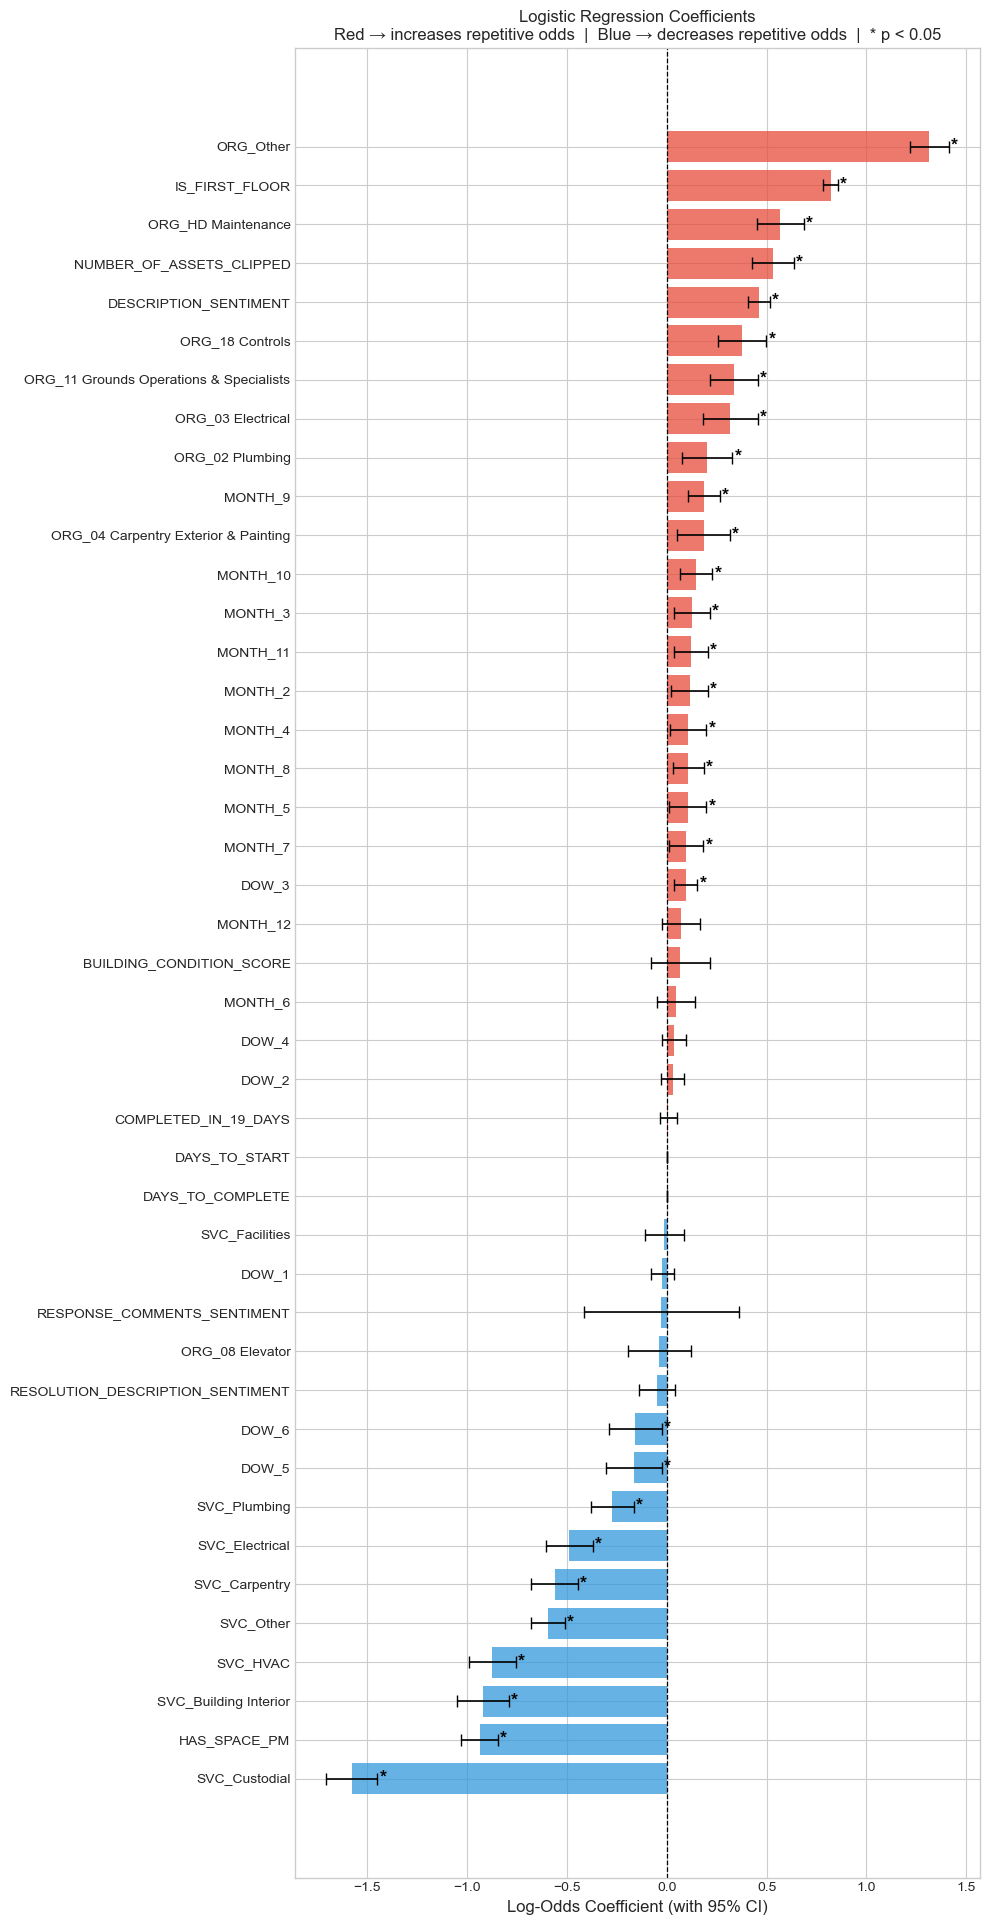

In [26]:
# --- Coefficient Plot ---
fig, ax = plt.subplots(figsize=(10, max(6, len(coef_df) * 0.45)))

colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.75)

# 95% confidence interval error bars
ax.errorbar(
    x=coef_df['Coefficient'],
    y=coef_df['Feature'],
    xerr=[
        coef_df['Coefficient'] - coef_df['CI_Lower'],
        coef_df['CI_Upper'] - coef_df['Coefficient']
    ],
    fmt='none', color='black', capsize=4, linewidth=1.2
)

ax.axvline(0, color='black', linewidth=0.9, linestyle='--')

# Mark statistically significant features with *
for i, row in coef_df.iterrows():
    if row['Significant']:
        x_pos = row['CI_Upper'] + 0.01
        ax.text(x_pos, i, '*', va='center', fontsize=13, color='black', fontweight='bold')

ax.set_xlabel('Log-Odds Coefficient (with 95% CI)', fontsize=12)
ax.set_title(
    'Logistic Regression Coefficients\n'
    'Red → increases repetitive odds  |  Blue → decreases repetitive odds  |  * p < 0.05',
    fontsize=12
)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

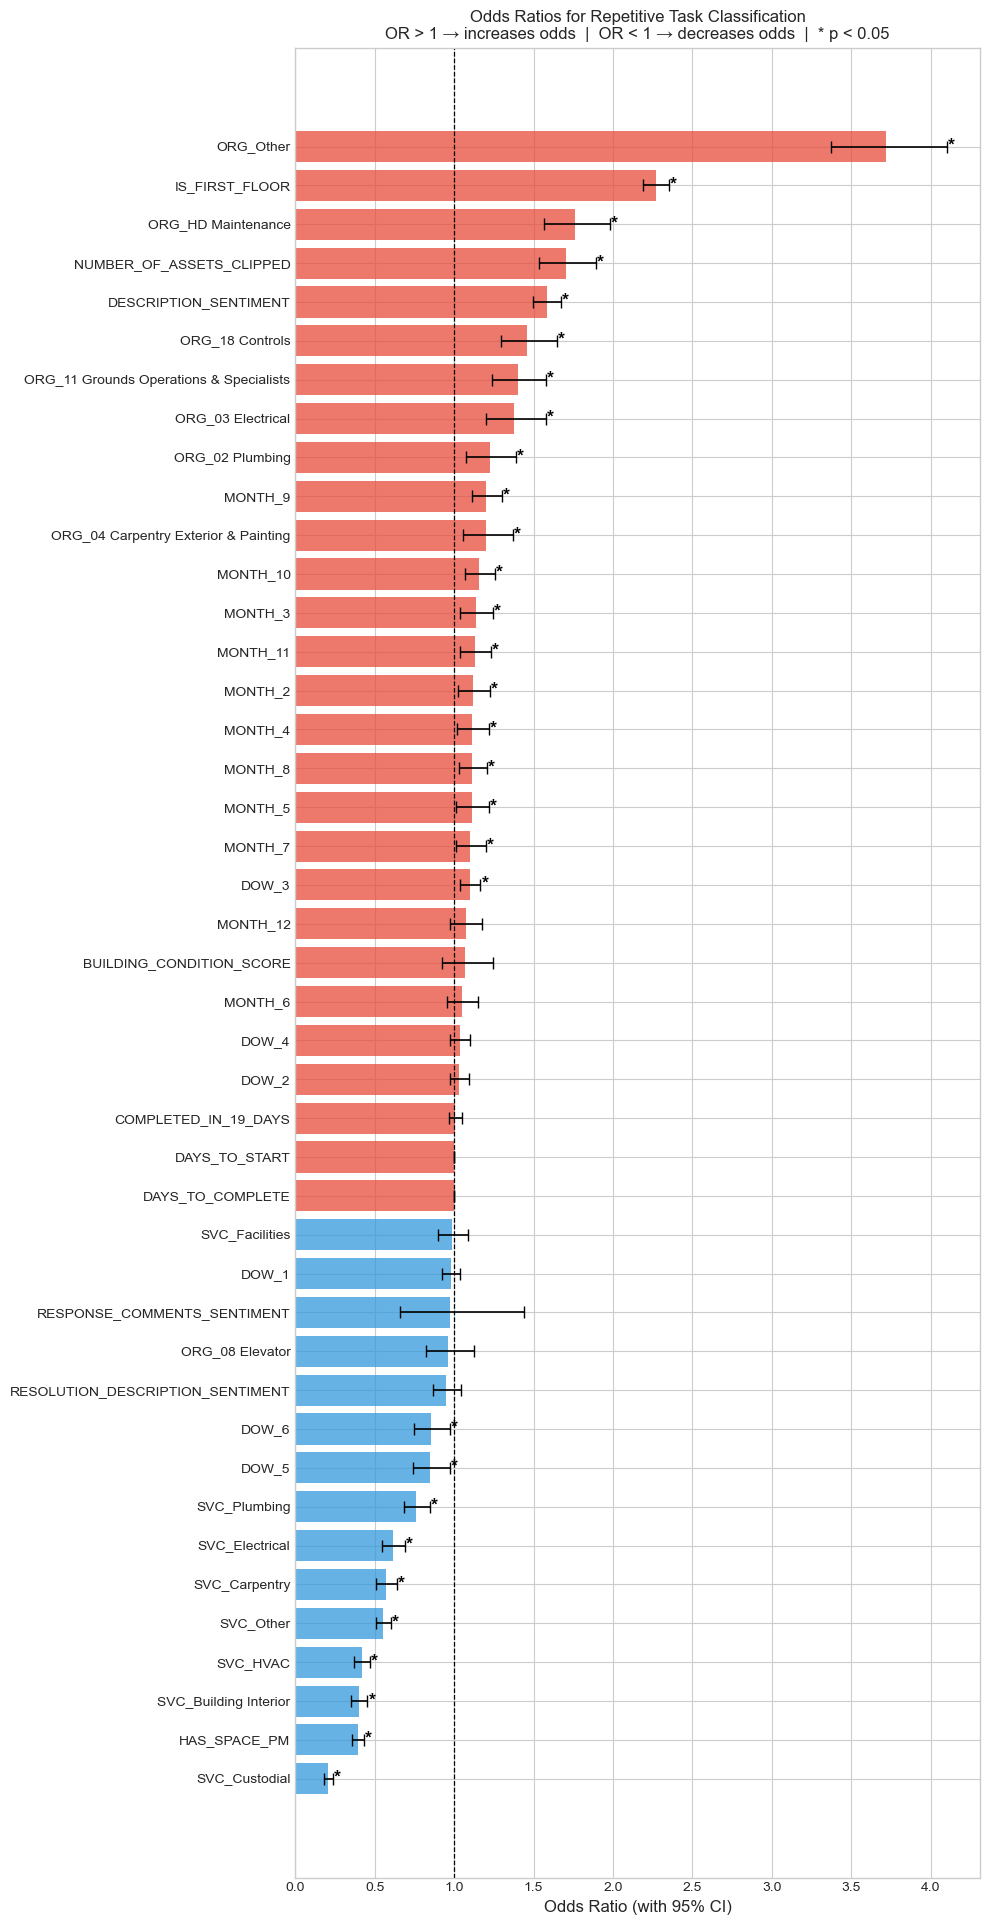

In [27]:
# --- Odds Ratio Plot (easier to interpret) ---
fig, ax = plt.subplots(figsize=(10, max(6, len(coef_df) * 0.45)))

or_colors = ['#e74c3c' if o > 1 else '#3498db' for o in coef_df['Odds_Ratio']]
ax.barh(coef_df['Feature'], coef_df['Odds_Ratio'], color=or_colors, alpha=0.75)

# CI on odds ratio scale
ax.errorbar(
    x=coef_df['Odds_Ratio'],
    y=coef_df['Feature'],
    xerr=[
        coef_df['Odds_Ratio'] - np.exp(coef_df['CI_Lower']),
        np.exp(coef_df['CI_Upper']) - coef_df['Odds_Ratio']
    ],
    fmt='none', color='black', capsize=4, linewidth=1.2
)

ax.axvline(1, color='black', linewidth=0.9, linestyle='--')

for i, row in coef_df.iterrows():
    if row['Significant']:
        x_pos = np.exp(row['CI_Upper']) + 0.005
        ax.text(x_pos, i, '*', va='center', fontsize=13, color='black', fontweight='bold')

ax.set_xlabel('Odds Ratio (with 95% CI)', fontsize=12)
ax.set_title(
    'Odds Ratios for Repetitive Task Classification\n'
    'OR > 1 → increases odds  |  OR < 1 → decreases odds  |  * p < 0.05',
    fontsize=12
)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

The logistic regression above provides **interpretable weights** (log-odds coefficients and odds ratios) for each feature. Key things to look for:

- **`BUILDING_CONDITION_SCORE`**: A high corrective-to-total ratio signals a building in poor condition. If significant and positive, buildings with more reactive (vs. preventive) maintenance are more prone to repetitive tickets.
- **`HAS_SPACE_PM`**: If negative and significant, spaces with proactive maintenance coverage have lower odds of corrective tasks recurring — supporting the case for expanding PM programs.
- **`SVC_*` (Service Class dummies)**: Identifies which trades (HVAC, Plumbing, Electrical, etc.) have elevated rates of repetitive failures relative to the reference class.

**Next steps (from `todo.md`)**:
- [ ] LDA analysis to identify latent topic structure in ticket descriptions
- [ ] Further narrowing of the feature space based on significance and VIF results above